In [35]:
"""Predict dPdK on AMIP models using trained HadGEM ensemble and compare to leave-one-out AMIP mean."""

import glob
import json
import os
from pathlib import Path

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from unet import ProbUNet

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
base_channels = 8
gn_groups = 1
kernel_size = 3
num_bins = 64
lat_dim = 128
batch_size = 11

dP_min = -700
dP_max = 1200

ens_name = (
    f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{base_channels}_k{kernel_size}_"
    f"{lat_dim}x_dPbins{num_bins}_gn{gn_groups}_dpmin{dP_min}_dPmax{dP_max}_sigma0.6"
)
ens_dir = Path("/Users/ewellmeyer/Documents/research/weights") / ens_name

amip_pr_path = "/Users/ewellmeyer/Documents/research/AMIP/AMIP_PR_his_rg128.nc"
amip_dlogpdk_dir = "/Users/ewellmeyer/Documents/research/AMIP/regridded/rg_128x192/dlogPdK"
landmask_file = "/Users/ewellmeyer/Documents/research/HadGEM/hadgem_landmask_rg128.nc"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================================================================
# 2. LOAD MODEL METADATA
# ==============================================================================
with open(ens_dir / "norm_stats.json", "r") as f:
    ns = json.load(f)
x_mean = np.array(ns["x_mean"], dtype=np.float32)
x_std = np.array(ns["x_std"], dtype=np.float32)
y_mean = float(ns["y_mean"])
y_std = float(ns["y_std"])

with open(ens_dir / "born_bins.json", "r") as f:
    bin_info = json.load(f)
bin_centers = np.array(bin_info["bin_centers_norm"], dtype=np.float32)
bin_centers_t = torch.as_tensor(bin_centers, dtype=torch.float32, device=device).view(1, -1, 1, 1)

# ==============================================================================
# 3. LOAD AMIP DATA
# ==============================================================================
# Historic precipitation (mm/yr)
ds_pr = xr.open_dataset(amip_pr_path)
amip_pr = ds_pr['PR'].values  # (11, 128, 192)
model_names = [str(r) for r in ds_pr['realization'].values]
lats = ds_pr['latitude'].values
lons = ds_pr['longitude'].values
ds_pr.close()

# Short model names for display
short_names = [m.split('_')[0] for m in model_names]
n_models = len(model_names)
print(f"AMIP models ({n_models}): {short_names}")

# Load dlogPdK files and convert to dPdK = PR_his * dlogPdK
dlogpdk_files = sorted(glob.glob(os.path.join(amip_dlogpdk_dir, "*.nc")))
assert len(dlogpdk_files) == n_models, f"Expected {n_models} files, found {len(dlogpdk_files)}"

amip_dpdk = np.zeros((n_models, 128, 192), dtype=np.float32)
for i, (name, fpath) in enumerate(zip(model_names, dlogpdk_files)):
    ds = xr.open_dataset(fpath)
    dlogpdk = ds['dlogPdK'].values.squeeze()  # (128, 192)
    ds.close()
    # dPdK = P_his * dlogPdK  (since dlogPdK = (1/P)(dP/dK))
    amip_dpdk[i] = amip_pr[i] * dlogpdk
    print(f"  {short_names[i]}: dPdK range [{amip_dpdk[i].min():.1f}, {amip_dpdk[i].max():.1f}]")

# Landmask and lat weights
ds_lm = xr.open_dataset(landmask_file)
landmask = ds_lm['land_mask'].values.astype(bool)
ds_lm.close()

lat_weights = np.cos(np.deg2rad(lats)).astype(np.float32)
lat_weights = lat_weights / lat_weights.mean()

# ==============================================================================
# 4. NN PREDICTION ON AMIP INPUTS
# ==============================================================================
# Normalize inputs using HadGEM training stats
X_amip = amip_pr[:, np.newaxis, :, :]  # (11, 1, 128, 192)
X_amip_norm = (X_amip - x_mean[None, :, None, None]) / x_std[None, :, None, None]

# Load ensemble members
model_files = sorted(glob.glob(str(ens_dir / f"{ens_dir.name}_member*.pth")))
n_ens = len(model_files)
print(f"\nLoading {n_ens} ensemble members...")

models = []
for path in model_files:
    model = ProbUNet(1, base_channels, kernel_size, 0.0, num_bins, gn_groups=gn_groups).to(device)
    ckpt = torch.load(path, map_location=device)
    state = ckpt['model'] if 'model' in ckpt else ckpt
    model.load_state_dict(state, strict=False)
    model.eval()
    models.append(model)

# Run inference: store per-member predictions
all_mu = np.zeros((n_ens, n_models, 128, 192), dtype=np.float32)
xb = torch.as_tensor(X_amip_norm, dtype=torch.float32, device=device)

for m_idx, model in enumerate(models):
    with torch.inference_mode():
        probs = model.forward_components(xb).float()
        mu_norm = (probs * bin_centers_t).sum(dim=1)
        mu = mu_norm * y_std + y_mean
    all_mu[m_idx] = mu.cpu().numpy()

# Ensemble mean prediction
nn_pred = all_mu.mean(axis=0)  # (11, 128, 192)
print(f"NN prediction shape: {nn_pred.shape}")

Using device: mps
AMIP models (11): ['BCC-CSM2-MR', 'CESM2', 'CNRM-CM6-1', 'CanESM5', 'E3SM-1-0', 'GFDL-CM4', 'HadGEM3-GC31-LL', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0', 'TaiESM1']
  BCC-CSM2-MR: dPdK range [-364.5, 527.7]
  CESM2: dPdK range [-234.6, 224.9]
  CNRM-CM6-1: dPdK range [-179.0, 532.1]
  CanESM5: dPdK range [-199.6, 392.0]
  E3SM-1-0: dPdK range [-546.8, 270.2]
  GFDL-CM4: dPdK range [-238.5, 299.9]
  HadGEM3-GC31-LL: dPdK range [-308.9, 432.6]
  IPSL-CM6A-LR: dPdK range [-3479.3, 748.5]
  MIROC6: dPdK range [-535.2, 442.1]
  MRI-ESM2-0: dPdK range [-339.9, 427.1]
  TaiESM1: dPdK range [-397.6, 517.2]

Loading 3 ensemble members...
NN prediction shape: (11, 128, 192)


In [36]:
# ==============================================================================
# 5. LEAVE-ONE-OUT AMIP MEAN BASELINE
# ==============================================================================
# For each model i, the LOO baseline is the mean of all OTHER models' dPdK
amip_loo_mean = np.zeros_like(amip_dpdk)
for i in range(n_models):
    mask = np.ones(n_models, dtype=bool)
    mask[i] = False
    amip_loo_mean[i] = amip_dpdk[mask].mean(axis=0)

# ==============================================================================
# 6. COMPUTE RMSE: NN vs LOO baseline
# ==============================================================================
denom_land = float((landmask * lat_weights[:, None]).sum() + 1e-12)

def weighted_rmse(pred, truth, weights):
    """Per-sample weighted RMSE."""
    se = (pred - truth) ** 2 * weights[None, :, None]
    return np.sqrt(se.mean(axis=(1, 2)))

def weighted_rmse_land(pred, truth, weights, lmask):
    """Per-sample land-only weighted RMSE."""
    denom = float((lmask * weights[:, None]).sum() + 1e-12)
    se = (pred - truth) ** 2 * weights[None, :, None] * lmask[None]
    return np.sqrt(se.sum(axis=(1, 2)) / denom)

nn_rmse = weighted_rmse(nn_pred, amip_dpdk, lat_weights)
loo_rmse = weighted_rmse(amip_loo_mean, amip_dpdk, lat_weights)
nn_rmse_land = weighted_rmse_land(nn_pred, amip_dpdk, lat_weights, landmask)
loo_rmse_land = weighted_rmse_land(amip_loo_mean, amip_dpdk, lat_weights, landmask)

print(f"{'Model':<22s} {'NN RMSE':>10s} {'LOO RMSE':>10s} {'Improv%':>8s}  |  {'NN Land':>10s} {'LOO Land':>10s} {'Improv%':>8s}")
print("-" * 95)
for i in range(n_models):
    imp = (1 - nn_rmse[i] / (loo_rmse[i] + 1e-12)) * 100
    imp_l = (1 - nn_rmse_land[i] / (loo_rmse_land[i] + 1e-12)) * 100
    print(f"{short_names[i]:<22s} {nn_rmse[i]:10.2f} {loo_rmse[i]:10.2f} {imp:+8.1f}%  |  {nn_rmse_land[i]:10.2f} {loo_rmse_land[i]:10.2f} {imp_l:+8.1f}%")

print(f"\n{'MEAN':<22s} {nn_rmse.mean():10.2f} {loo_rmse.mean():10.2f} {(1-nn_rmse.mean()/(loo_rmse.mean()+1e-12))*100:+8.1f}%  |  {nn_rmse_land.mean():10.2f} {loo_rmse_land.mean():10.2f} {(1-nn_rmse_land.mean()/(loo_rmse_land.mean()+1e-12))*100:+8.1f}%")

Model                     NN RMSE   LOO RMSE  Improv%  |     NN Land   LOO Land  Improv%
-----------------------------------------------------------------------------------------------
BCC-CSM2-MR                 54.39      36.92    -47.3%  |       62.59      44.61    -40.3%
CESM2                       43.24      25.86    -67.2%  |       42.90      28.06    -52.9%
CNRM-CM6-1                  50.57      35.36    -43.0%  |       52.74      37.85    -39.3%
CanESM5                     45.81      35.03    -30.8%  |       52.58      37.90    -38.7%
E3SM-1-0                    55.92      34.07    -64.1%  |       63.32      39.56    -60.1%
GFDL-CM4                    51.33      30.85    -66.4%  |       57.20      37.20    -53.8%
HadGEM3-GC31-LL             41.02      35.47    -15.7%  |       28.26      32.76    +13.8%
IPSL-CM6A-LR                87.33      72.76    -20.0%  |      121.22      96.94    -25.0%
MIROC6                      73.65      54.95    -34.0%  |       67.72      45.48    -48

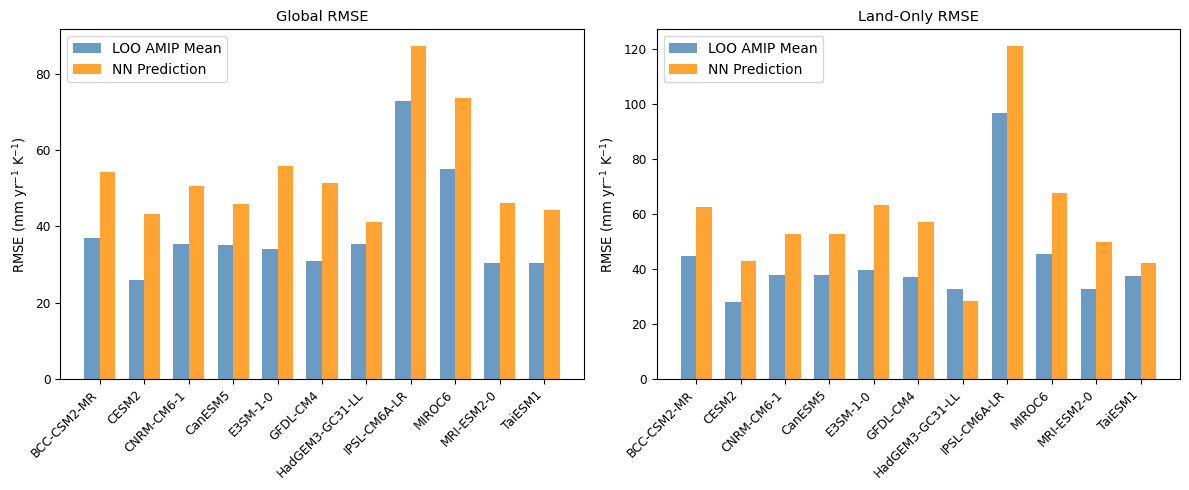

In [37]:
# ==============================================================================
# 7. SUMMARY FIGURES
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pos = np.arange(n_models)
width = 0.35

# Global RMSE bar chart
ax = axes[0]
ax.bar(x_pos - width/2, loo_rmse, width, label='LOO AMIP Mean', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, nn_rmse, width, label='NN Prediction', color='darkorange', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('RMSE (mm yr$^{-1}$ K$^{-1}$)')
ax.set_title('Global RMSE')
ax.legend()

# Land RMSE bar chart
ax = axes[1]
ax.bar(x_pos - width/2, loo_rmse_land, width, label='LOO AMIP Mean', color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, nn_rmse_land, width, label='NN Prediction', color='darkorange', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('RMSE (mm yr$^{-1}$ K$^{-1}$)')
ax.set_title('Land-Only RMSE')
ax.legend()

plt.tight_layout()
plt.show()

/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/ewellmeyer/miniconda3/envs/ml/lib/python3.10/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)


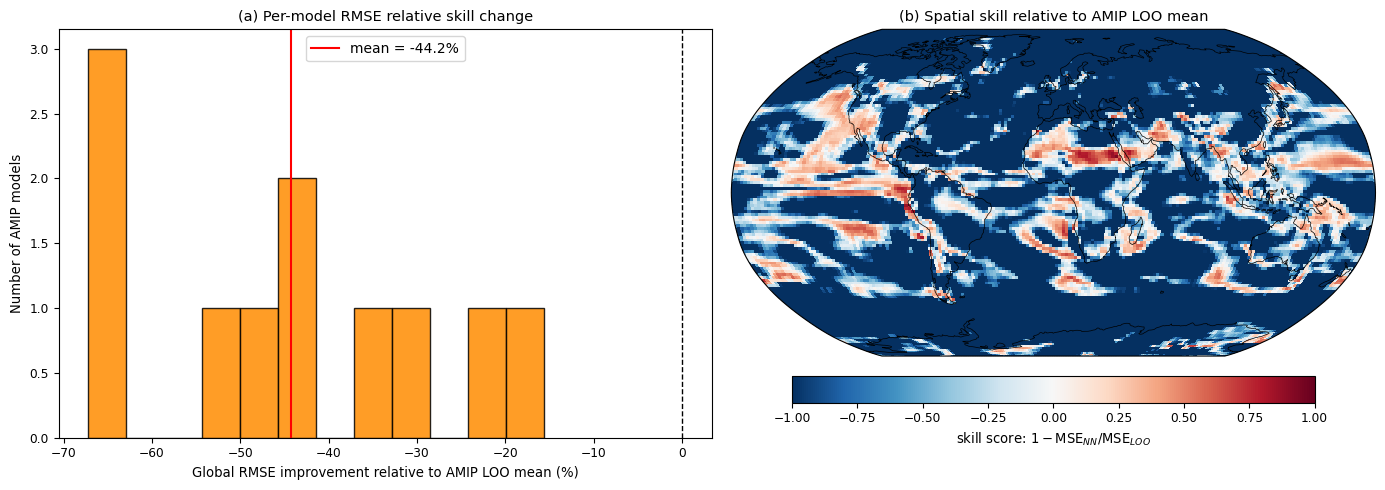

In [38]:
# ==============================================================================
# 9. NN vs LOO AMIP: improvement histogram + skill score map
# ==============================================================================
improv_pct = (1 - nn_rmse / (loo_rmse + 1e-12)) * 100

# Per-gridpoint skill score averaged across models: 1 - <MSE_NN>/<MSE_LOO>
se_nn = (nn_pred - amip_dpdk) ** 2
se_loo = (amip_loo_mean - amip_dpdk) ** 2
mse_nn_map = se_nn.mean(axis=0)
mse_loo_map = se_loo.mean(axis=0)
skill_map = 1.0 - mse_nn_map / (mse_loo_map + 1e-12)

fig = plt.figure(figsize=(14, 5))

# Panel A: histogram of per-model global RMSE improvement (%)
axA = fig.add_subplot(1, 2, 1)
axA.hist(improv_pct, bins=12, color='darkorange', edgecolor='black', alpha=0.85)
axA.axvline(0, color='k', lw=1, ls='--')
axA.axvline(improv_pct.mean(), color='red', lw=1.5, ls='-',
            label=f'mean = {improv_pct.mean():+.1f}%')
axA.set_xlabel('Global RMSE improvement relative to AMIP LOO mean (%)')
axA.set_ylabel('Number of AMIP models')
axA.set_title('(a) Per-model RMSE relative skill change')
axA.legend()

# Panel B: skill score map (NN vs LOO)
axB = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())
axB.set_global()
axB.coastlines(linewidth=0.5)
im = axB.pcolormesh(
    lons, lats, skill_map,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', vmin=-1, vmax=1,
)
axB.set_title('(b) Spatial skill relative to AMIP LOO mean')
plt.colorbar(im, ax=axB, orientation='horizontal', pad=0.05, shrink=0.8,
             label='skill score: $1 - \\mathrm{MSE}_{NN}/\\mathrm{MSE}_{LOO}$')

plt.tight_layout()
plt.show()


In [39]:
# ==============================================================================
# 10. AMIP vs HadGEM PPE: ensemble statistics comparison
# ==============================================================================
hg_pr_file = "/Users/ewellmeyer/Documents/research/HadGEM/GA789_PR_his_rg128.nc"
hg_dpdk_file = "/Users/ewellmeyer/Documents/research/HadGEM/GA789_dPdK_rg128.nc"

ds_hg_pr = xr.open_dataset(hg_pr_file)
hg_pr = ds_hg_pr['PR'].values.astype(np.float32)
ds_hg_pr.close()

ds_hg_dpdk = xr.open_dataset(hg_dpdk_file)
hg_dpdk = ds_hg_dpdk['dPdK'].values.astype(np.float32)
ds_hg_dpdk.close()

n_hg = hg_dpdk.shape[0]
print(f"HadGEM PPE members: {n_hg}")
print(f"AMIP models:        {n_models}")

# LOO means
hg_loo_mean = np.zeros_like(hg_dpdk)
for i in range(n_hg):
    mask = np.ones(n_hg, dtype=bool)
    mask[i] = False
    hg_loo_mean[i] = hg_dpdk[mask].mean(axis=0)

# Weighted helpers
def wmean(x, w):
    return float((x * w[None, :, None]).sum(axis=(1, 2)).mean() / w.sum() / x.shape[2])

def wmean_field(x, w):
    # area-weighted global mean of a (N, lat, lon) array, per-sample then averaged
    num = (x * w[None, :, None]).sum(axis=(1, 2))
    den = w.sum() * x.shape[2]
    return num / den

def wstd_field(x, w):
    mu = wmean_field(x, w)[:, None, None]
    num = ((x - mu) ** 2 * w[None, :, None]).sum(axis=(1, 2))
    den = w.sum() * x.shape[2]
    return np.sqrt(num / den)

# Global area-weighted stats
amip_mean = wmean_field(amip_dpdk, lat_weights)
amip_std  = wstd_field(amip_dpdk, lat_weights)
hg_mean   = wmean_field(hg_dpdk, lat_weights)
hg_std    = wstd_field(hg_dpdk, lat_weights)

amip_pr_mean = wmean_field(amip_pr, lat_weights)
hg_pr_mean   = wmean_field(hg_pr, lat_weights)

# LOO RMSE (per member, vs truth) — same metric used for NN comparison
amip_loo_rmse = weighted_rmse(amip_loo_mean, amip_dpdk, lat_weights)
hg_loo_rmse   = weighted_rmse(hg_loo_mean,   hg_dpdk,   lat_weights)
amip_loo_rmse_land = weighted_rmse_land(amip_loo_mean, amip_dpdk, lat_weights, landmask)
hg_loo_rmse_land   = weighted_rmse_land(hg_loo_mean,   hg_dpdk,   lat_weights, landmask)

# Ensemble spread: stdev across members at each gridpoint, then area-weighted global mean
amip_spread = float(((amip_dpdk.std(axis=0) ** 2 * lat_weights[:, None]).sum()
                     / (lat_weights.sum() * amip_dpdk.shape[2])) ** 0.5)
hg_spread   = float(((hg_dpdk.std(axis=0) ** 2 * lat_weights[:, None]).sum()
                     / (lat_weights.sum() * hg_dpdk.shape[2])) ** 0.5)

print("\n" + "=" * 72)
print(f"{'Statistic':<38s} {'AMIP':>14s} {'HadGEM PPE':>16s}")
print("-" * 72)
print(f"{'N members':<38s} {n_models:>14d} {n_hg:>16d}")
print(f"{'Mean PR (mm/yr)':<38s} {amip_pr_mean.mean():>14.2f} {hg_pr_mean.mean():>16.2f}")
print(f"{'Mean dPdK (mm/yr/K)':<38s} {amip_mean.mean():>14.2f} {hg_mean.mean():>16.2f}")
print(f"{'Across-member spread of means':<38s} {amip_mean.std():>14.2f} {hg_mean.std():>16.2f}")
print(f"{'Mean within-member spatial std':<38s} {amip_std.mean():>14.2f} {hg_std.mean():>16.2f}")
print(f"{'Ensemble spread (gridpoint std)':<38s} {amip_spread:>14.2f} {hg_spread:>16.2f}")
print(f"{'LOO RMSE — global (mean)':<38s} {amip_loo_rmse.mean():>14.2f} {hg_loo_rmse.mean():>16.2f}")
print(f"{'LOO RMSE — global (median)':<38s} {np.median(amip_loo_rmse):>14.2f} {np.median(hg_loo_rmse):>16.2f}")
print(f"{'LOO RMSE — land  (mean)':<38s} {amip_loo_rmse_land.mean():>14.2f} {hg_loo_rmse_land.mean():>16.2f}")
print(f"{'dPdK min (member-min)':<38s} {amip_dpdk.min():>14.2f} {hg_dpdk.min():>16.2f}")
print(f"{'dPdK max (member-max)':<38s} {amip_dpdk.max():>14.2f} {hg_dpdk.max():>16.2f}")
print("=" * 72)
print(f"AMIP LOO RMSE / HadGEM LOO RMSE (global) = "
      f"{amip_loo_rmse.mean() / hg_loo_rmse.mean():.2f}x")
print(f"AMIP spread / HadGEM spread              = "
      f"{amip_spread / hg_spread:.2f}x")


HadGEM PPE members: 1515
AMIP models:        11

Statistic                                        AMIP       HadGEM PPE
------------------------------------------------------------------------
N members                                          11             1515
Mean PR (mm/yr)                               1098.56          1122.45
Mean dPdK (mm/yr/K)                             27.27            40.41
Across-member spread of means                    2.57             6.60
Mean within-member spatial std                  57.31           110.54
Ensemble spread (gridpoint std)                 36.81            76.75
LOO RMSE — global (mean)                        38.36            72.89
LOO RMSE — global (median)                      35.03            65.15
LOO RMSE — land  (mean)                         42.76            67.78
dPdK min (member-min)                        -3479.27        -15616.76
dPdK max (member-max)                          748.47          5004.12
AMIP LOO RMSE / HadGEM LOO

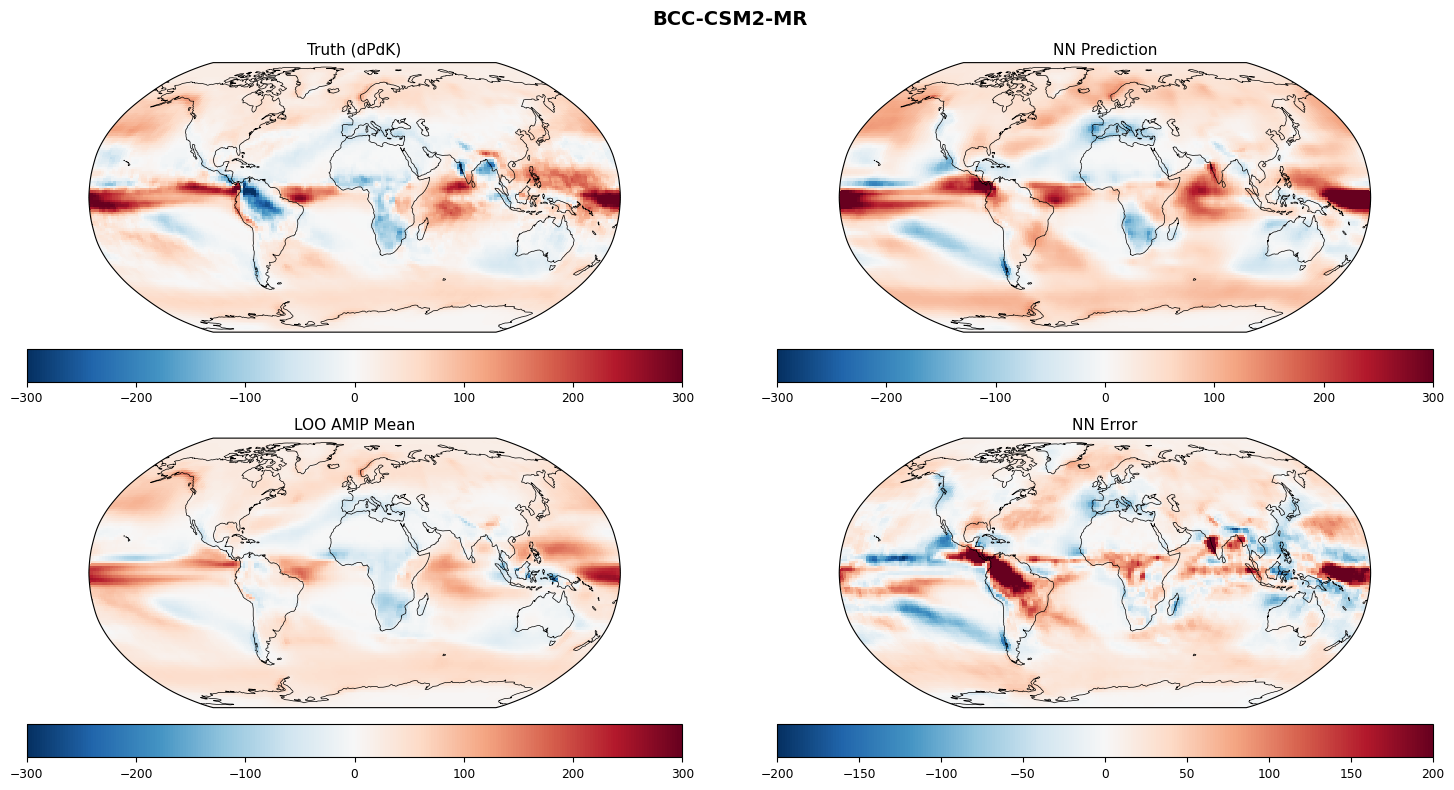

In [41]:
# ==============================================================================
# 8. MAP COMPARISON: per-model truth, NN pred, LOO mean, errors
# ==============================================================================
import warnings

# Cartopy/Shapely can emit this during projected map rendering; it does not
# indicate a problem with the plotted dPdK fields.
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in buffer",
    category=RuntimeWarning,
)

vmin, vmax = -300, 300
err_vmin, err_vmax = -200, 200
proj = ccrs.Robinson()

for i in range(1):
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), subplot_kw={'projection': proj})
    fig.suptitle(f"{short_names[i]}", fontsize=14, fontweight='bold')

    panels = [
        (axes[0, 0], amip_dpdk[i], 'Truth (dPdK)', vmin, vmax, 'RdBu_r'),
        (axes[0, 1], nn_pred[i], 'NN Prediction', vmin, vmax, 'RdBu_r'),
        (axes[1, 0], amip_loo_mean[i], 'LOO AMIP Mean', vmin, vmax, 'RdBu_r'),
        (axes[1, 1], nn_pred[i] - amip_dpdk[i], 'NN Error', err_vmin, err_vmax, 'RdBu_r'),
    ]

    for ax, data, title, v0, v1, cmap in panels:
        ax.set_global()
        ax.coastlines(linewidth=0.5)
        data_plot = np.ma.masked_invalid(np.asarray(data))
        with warnings.catch_warnings():
            # Cartopy can emit many RuntimeWarnings when projecting masked cells.
            warnings.filterwarnings("ignore", category=RuntimeWarning)
            im = ax.pcolormesh(
                lons, lats, data_plot,
                transform=ccrs.PlateCarree(),
                cmap=cmap, vmin=v0, vmax=v1,
                shading='auto',
            )
        ax.set_title(title)
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Loaded AMIP dPdK from AMIP_dPdK_rg128.nc; N=11
Loaded HadGEM dPdK from GA789_dPdK_rg128.nc; N=1515
Saved: /Users/ewellmeyer/Documents/research/scripts/precip_pr_dpdk/figures/amip_vs_hadgem_ppe_member_stats_pub.png
Saved: /Users/ewellmeyer/Documents/research/scripts/precip_pr_dpdk/figures/amip_vs_hadgem_ppe_member_stats_pub.pdf


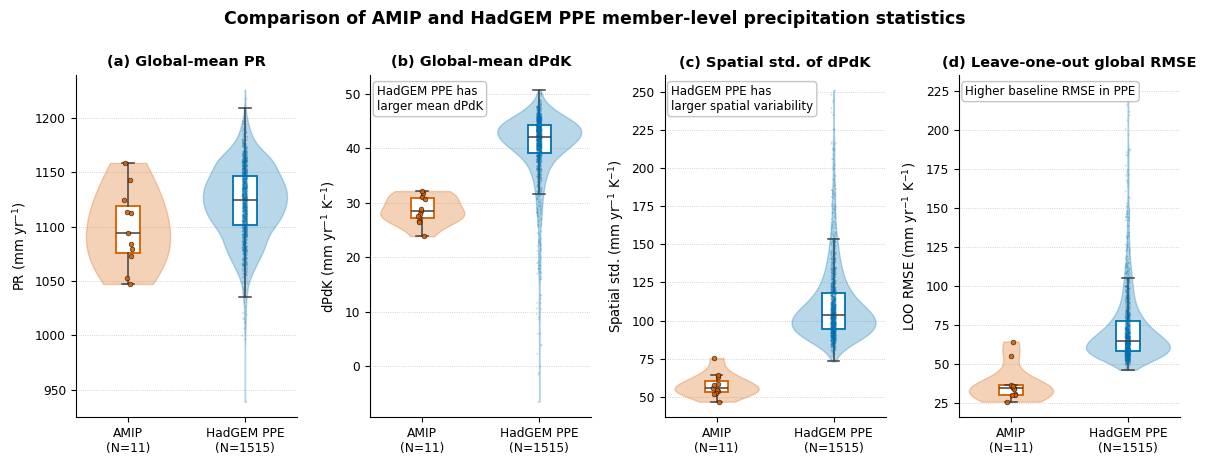

In [42]:
# ==============================================================================
# 12. Publication-quality figure: AMIP vs HadGEM PPE member-level statistics
# ==============================================================================
# Self-contained, matplotlib-only. Reads AMIP and HadGEM PPE fields, computes
# per-member statistics, and draws a compact GRL-style supporting figure.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


# ------------------------------------------------------------------------------
# Step 1: Declare input file locations and the output directory.
# ------------------------------------------------------------------------------
amip_pr_candidates = [
    Path("/Users/ewellmeyer/Documents/research/AMIP/AMIP_PR_his_rg128.nc"),
    Path("/Users/ewellmeyer/Documents/research/AMIP/processed/rg_128x192/AMIP_PR_clim_rg128.nc"),
]
amip_dpdk_candidates = [
    Path("/Users/ewellmeyer/Documents/research/AMIP/processed/rg_128x192/AMIP_dPdK_rg128.nc"),
]
hg_pr_path = Path("/Users/ewellmeyer/Documents/research/HadGEM/GA789_PR_his_rg128.nc")
hg_dpdk_path = Path("/Users/ewellmeyer/Documents/research/HadGEM/GA789_dPdK_rg128.nc")

out_dir = Path("/Users/ewellmeyer/Documents/research/scripts/precip_pr_dpdk/figures")
out_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------------------------
# Step 2: Helpers for locating files and loading fields/coords out of a dataset.
# ------------------------------------------------------------------------------
def _first_existing(paths):
    """Return the first path in `paths` that exists on disk."""
    for path in paths:
        if path.exists():
            return path
    raise FileNotFoundError("None of these files exist: " + ", ".join(str(p) for p in paths))


def _load_field(path, preferred_vars):
    """Load a (members, lat, lon) field plus lat/lon coords from a NetCDF file."""
    with xr.open_dataset(path) as ds:
        # Pick the first preferred variable that exists; otherwise take the first data_var.
        var_name = next((name for name in preferred_vars if name in ds.data_vars), None)
        if var_name is None:
            var_name = list(ds.data_vars)[0]
        arr = ds[var_name].values.astype(np.float32)

        # Extract latitude coordinate under any of the common names.
        lat = None
        for name in ("latitude", "lat", "y"):
            if name in ds.coords:
                lat = ds[name].values.astype(np.float32)
                break

        # Extract longitude coordinate under any of the common names.
        lon = None
        for name in ("longitude", "lon", "x"):
            if name in ds.coords:
                lon = ds[name].values.astype(np.float32)
                break

    return arr, lat, lon, var_name


# ------------------------------------------------------------------------------
# Step 3: Resolve the input file paths (first one that exists wins).
# ------------------------------------------------------------------------------
amip_pr_path = _first_existing(amip_pr_candidates)
amip_dpdk_path = _first_existing(amip_dpdk_candidates)


# ------------------------------------------------------------------------------
# Step 4: Load the four fields and keep the first available lat/lon coords.
# ------------------------------------------------------------------------------
amip_pr, lats, lons, amip_pr_var = _load_field(
    amip_pr_path, ["PR", "pr", "precipitation_flux"]
)
amip_dpdk, _, _, amip_dpdk_var = _load_field(
    amip_dpdk_path, ["dPdK", "dP_dK", "dPdP"]
)
hg_pr, hg_lats, hg_lons, hg_pr_var = _load_field(
    hg_pr_path, ["PR", "pr", "precipitation_flux"]
)
hg_dpdk, _, _, hg_dpdk_var = _load_field(
    hg_dpdk_path, ["dPdK", "dP_dK", "dPdP"]
)

# Fall back to HadGEM lats if the AMIP file didn't carry coordinates.
if lats is None:
    lats = hg_lats
if lats is None:
    raise ValueError("Could not infer latitude coordinates from AMIP or HadGEM files.")


# ------------------------------------------------------------------------------
# Step 5: Build area weights from cos(latitude) for area-weighted statistics.
# ------------------------------------------------------------------------------
lat_weights = np.cos(np.deg2rad(lats)).astype(np.float64)
lat_weights = np.clip(lat_weights, 0.0, None)


# ------------------------------------------------------------------------------
# Step 6: Statistical helpers used by every panel.
# ------------------------------------------------------------------------------
def area_weighted_mean_per_member(x, weights):
    """Global area-weighted mean, computed separately for each member."""
    x = np.asarray(x, dtype=np.float64)
    denom = weights.sum() * x.shape[2]
    return (x * weights[None, :, None]).sum(axis=(1, 2)) / denom


def area_weighted_spatial_std_per_member(x, weights):
    """Area-weighted spatial standard deviation, computed separately for each member."""
    x = np.asarray(x, dtype=np.float64)
    mu = area_weighted_mean_per_member(x, weights)[:, None, None]
    denom = weights.sum() * x.shape[2]
    var = ((x - mu) ** 2 * weights[None, :, None]).sum(axis=(1, 2)) / denom
    return np.sqrt(np.maximum(var, 0.0))


def leave_one_out_rmse_global(x, weights, batch_size=128):
    """Per-member global RMSE against the mean of every other member (leave-one-out)."""
    x = np.asarray(x, dtype=np.float64)
    n, _, width = x.shape

    # Total across members, used to form each LOO mean as (total - xb) / (n - 1).
    total = x.sum(axis=0, dtype=np.float64)
    denom = weights.sum() * width
    out = np.empty(n, dtype=np.float64)

    # Process in batches so the (batch, lat, lon) tensors stay small.
    for start in range(0, n, batch_size):
        stop = min(start + batch_size, n)
        xb = x[start:stop]
        loo = (total[None, :, :] - xb) / max(n - 1, 1)
        se = (loo - xb) ** 2
        out[start:stop] = np.sqrt((se * weights[None, :, None]).sum(axis=(1, 2)) / denom)

    return out


# ------------------------------------------------------------------------------
# Step 7: Compute the per-member statistics that drive the panels.
# ------------------------------------------------------------------------------
amip_pr_mean = area_weighted_mean_per_member(amip_pr, lat_weights)
hg_pr_mean = area_weighted_mean_per_member(hg_pr, lat_weights)

amip_dpdk_mean = area_weighted_mean_per_member(amip_dpdk, lat_weights)
hg_dpdk_mean = area_weighted_mean_per_member(hg_dpdk, lat_weights)

amip_dpdk_std = area_weighted_spatial_std_per_member(amip_dpdk, lat_weights)
hg_dpdk_std = area_weighted_spatial_std_per_member(hg_dpdk, lat_weights)


# ------------------------------------------------------------------------------
# Step 8: Try to add LOO RMSE as a fourth panel; degrade gracefully if it fails.
# ------------------------------------------------------------------------------
loo_available = True
try:
    amip_loo_rmse = leave_one_out_rmse_global(amip_dpdk, lat_weights, batch_size=16)
    hg_loo_rmse = leave_one_out_rmse_global(hg_dpdk, lat_weights, batch_size=128)
except Exception as exc:
    print(f"LOO RMSE could not be computed; making 3-panel figure instead. Reason: {exc}")
    loo_available = False


# ------------------------------------------------------------------------------
# Step 9: Report what was loaded so the cell output is self-documenting.
# ------------------------------------------------------------------------------
n_amip = int(amip_dpdk.shape[0])
n_hg = int(hg_dpdk.shape[0])
print(f"Loaded AMIP {amip_dpdk_var} from {amip_dpdk_path.name}; N={n_amip}")
print(f"Loaded HadGEM {hg_dpdk_var} from {hg_dpdk_path.name}; N={n_hg}")


# ------------------------------------------------------------------------------
# Step 10: Assemble panel specifications (title, ylabel, data, annotation).
# ------------------------------------------------------------------------------
panel_specs = [
    (
        "(a) Global-mean PR",
        "PR (mm yr$^{-1}$)",
        amip_pr_mean,
        hg_pr_mean,
        None,
    ),
    (
        "(b) Global-mean dPdK",
        "dPdK (mm yr$^{-1}$ K$^{-1}$)",
        amip_dpdk_mean,
        hg_dpdk_mean,
        "HadGEM PPE has\nlarger mean dPdK",
    ),
    (
        "(c) Spatial std. of dPdK",
        "Spatial std. (mm yr$^{-1}$ K$^{-1}$)",
        amip_dpdk_std,
        hg_dpdk_std,
        "HadGEM PPE has\nlarger spatial variability",
    ),
]
if loo_available:
    panel_specs.append(
        (
            "(d) Leave-one-out global RMSE",
            "LOO RMSE (mm yr$^{-1}$ K$^{-1}$)",
            amip_loo_rmse,
            hg_loo_rmse,
            "Higher baseline RMSE in PPE",
        )
    )


# ------------------------------------------------------------------------------
# Step 11: Figure-wide style choices: colors for each archive and RNG for jitter.
# ------------------------------------------------------------------------------
C_AMIP = "#D55E00"   # orange, used for every AMIP distribution
C_HG = "#0072B2"     # blue, used for every HadGEM PPE distribution
rng = np.random.default_rng(42)


def _jitter(n, width):
    """Uniform x-axis jitter of half-width `width`, for overlaid raw points."""
    return rng.uniform(-width, width, size=n)


# ------------------------------------------------------------------------------
# Step 12: Single-panel drawing routine. Each panel gets violin + box + points.
# ------------------------------------------------------------------------------
def _draw_distribution(ax, amip_values, hg_values, ylabel, title, note=None):
    data = [np.asarray(amip_values, dtype=np.float64),
            np.asarray(hg_values, dtype=np.float64)]
    colors = [C_AMIP, C_HG]
    positions = [0, 1]

    # Violin bodies show the full distribution shape.
    violins = ax.violinplot(
        data, positions=positions, widths=0.72,
        showmeans=False, showmedians=False, showextrema=False,
    )
    for body, color in zip(violins["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.28)
        body.set_linewidth(1.0)

    # Narrow boxplots overlay the quartiles and median on top of the violins.
    box = ax.boxplot(
        data, positions=positions, widths=0.20,
        patch_artist=True, showfliers=False, manage_ticks=False,
    )
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor("white")
        patch.set_edgecolor(color)
        patch.set_linewidth(1.3)
    for key in ("whiskers", "caps", "medians"):
        for artist in box[key]:
            artist.set_color("0.25")
            artist.set_linewidth(1.1)

    # Jittered raw points — AMIP's 11 members get larger, outlined markers;
    # HadGEM's ~1500 members use small translucent points to show density.
    ax.scatter(
        _jitter(len(data[0]), 0.04), data[0],
        s=12, color=C_AMIP, edgecolor="black", linewidth=0.35,
        alpha=0.9, zorder=3,
    )
    ax.scatter(
        1 + _jitter(len(data[1]), 0.02), data[1],
        s=2, color=C_HG, edgecolor="none",
        alpha=0.2, zorder=2, rasterized=True,
    )

    # Axis labeling, tick labels with sample sizes, and clean spines.
    ax.set_xticks(positions)
    ax.set_xticklabels([
        f"AMIP\n(N={len(data[0])})",
        f"HadGEM PPE\n(N={len(data[1])})",
    ])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Optional per-panel callout note.
    if note is not None:
        ax.text(
            0.03, 0.97, note,
            transform=ax.transAxes, ha="left", va="top",
            fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="0.75", alpha=0.9),
        )


# ------------------------------------------------------------------------------
# Step 13: Set readable figure-wide rcParams before building the figure.
# ------------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.8,
    "ytick.labelsize": 8.8,
})


# ------------------------------------------------------------------------------
# Step 14: Build the figure: 2x2 when LOO is available, otherwise 1x3.
# ------------------------------------------------------------------------------
# fig, axes = plt.subplots(2, 2, figsize=(10.8, 10))
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
axes = np.asarray(axes).ravel()


# ------------------------------------------------------------------------------
# Step 15: Draw each panel, then hide any unused axes (in case panel count drops).
# ------------------------------------------------------------------------------
for ax, (title, ylabel, amip_values, hg_values, note) in zip(axes, panel_specs):
    _draw_distribution(ax, amip_values, hg_values, ylabel, title, note=note)

for ax in axes[len(panel_specs):]:
    ax.set_visible(False)


# ------------------------------------------------------------------------------
# Step 16: Figure suptitle and a takeaway sentence anchored at the bottom.
# ------------------------------------------------------------------------------
fig.suptitle(
    "Comparison of AMIP and HadGEM PPE member-level precipitation statistics",
    fontsize=12.5, fontweight="bold", y=0.995,
)


# ------------------------------------------------------------------------------
# Step 17: Tighten layout leaving room for the suptitle and the bottom annotation.
# ------------------------------------------------------------------------------
fig.tight_layout(rect=[0, 0.075, 1, 1])


# ------------------------------------------------------------------------------
# Step 18: Save high-resolution PNG and vector PDF, then display the figure.
# ------------------------------------------------------------------------------
png_path = out_dir / "amip_vs_hadgem_ppe_member_stats_pub.png"
pdf_path = out_dir / "amip_vs_hadgem_ppe_member_stats_pub.pdf"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

plt.show()
